<img src=https://courseware.decoded.com/images/decoded/logo-decoded.png align=left width=100px/> 

# Regression and Classification
---
<small>© COPYRIGHT 2026 DECODED LIMITED. ALL RIGHTS RESERVED. Web: https://decoded.com/ </small>

### Summary
In this chapter we will dive into the powerful world of classification, a fundamental task in the field of machine learning and data analysis. Through a combination of theory, hands-on exercises, and real-world examples, we will explore various classification algorithms, discuss evaluation metrics, and uncover strategies for feature selection and model optimisation. 



### Learning Objectives
- Understand the concept of classification and its importance in machine learning and data analysis
- Identify different types of classification problems, such as binary, multi-class, and multi-label classification
- Understand common classification algorithms, including decision trees, logistic regression, and k-nearest neighbors (k-NN)
- Compare and contrast the strengths and limitations of various classification algorithms, enabling informed algorithm selection for different datasets
- Evaluate the performance of classification models using appropriate evaluation metrics, such as accuracy, precision, recall, F1 score, and ROC curves
- Implement classification algorithms in Python using popular libraries such as scikit-learn
- Gain hands-on experience in preprocessing and feature engineering techniques to enhance classification model performance
- Apply best practices for model training, testing, and validation, including strategies for cross-validation and hyperparameter tuning to optimise classification models


---

### Overview


[**What is classification?**](#what_is_classification)
- What is classification?
- How is classification different than regression? 
- What are the different types of classification problems? 
- What are example uses of classification? 
- *Challenge*: Discuss applications of classification

[**What is a classification model?**](#classification_models)
- What are examples of different classification algorithms? 
- What is logistic regression algorithm? 
- What is the Decision Tree algorithm?
- *Challenge*: Compare applications of linear regression and logistic regression 

[**How do I interpret classification models?**](#interpreting_classification_models)
- How do I interpret a logistic regression model?
- How do I interpret a Decision Tree model?
- *Challenge*: Create a decision tree by hand



[**How to ML algorithms find classification models?**](#ml_algorithms)
- How does the logistic regression algorithm find a logistic regression model? 
- How do you implement logistic regression in Python?
- *Demo*: Use `LogisticRegression()` from `sklearn` to train a model
- How does the Decision Tree algorithm find a Decision Tree model?
- How do you implement Decision Trees in Python?
- *Demo*: Use `DecisionTreeClassifier()` from `sklearn` to train a model

[**How do I choose between classification models?**](#model_selection)
- What is model selection?
- What is a validation set?  
- How do you use grid search to tune hyperparameters?
- *Challenge*: Use `GridSearchCV` from `sklearn` to perform model selection

[**How do I evaluate classification models?**](#model_evaluation)
- Why are models evaluated on a test set?
- What is a confusion matrix? 
- *Challenge*: Use `confusion_matrix` from `sklearn` to display classification model outcomes 

### Introductions

#### Purpose: What is the aim of the content?

The purpose of this introductory workshop on classification is to equip learners with the knowledge and skills necessary to effectively tackle classification problems in machine learning and data analysis. Classification is a fundamental task that involves categorizing data into distinct classes or categories based on their features. Understanding how to classify data accurately is crucial in various domains, including finance, healthcare, marketing, and many others. This workshop aims to provide a comprehensive overview of classification concepts, algorithms, evaluation techniques, and implementation in Python. 


#### Objectives: What will I learn?
- Understand the concept of classification and its importance in machine learning and data analysis
- Identify different types of classification problems, such as binary, multi-class, and multi-label classification
- Understand common classification algorithms, including decision trees, logistic regression, and k-nearest neighbors (k-NN)
- Compare and contrast the strengths and limitations of various classification algorithms, enabling informed algorithm selection for different datasets
- Evaluate the performance of classification models using appropriate evaluation metrics, such as accuracy, precision, recall, F1 score, and ROC curves
- Implement classification algorithms in Python using popular libraries such as scikit-learn
- Gain hands-on experience in preprocessing and feature engineering techniques to enhance classification model performance
- Apply best practices for model training, testing, and validation, including strategies for cross-validation and hyperparameter tuning to optimise classification models

#### Process: How will I learn this content?
- Throughout the workshop, we will:
    - brainstorm and discuss ideas together
    - work on demos and challenges
    - use whiteboard to explain complex concepts
    - answer menti and quiz questions

#### Applications: Why study this?


Classification is a machine learning task that predicts the categorical output for unlabelled data points. There are a number of classification algorithms that can be used for a various different datasets and contexts. 

The process of recognising and classifying instances into preset categories is something we naturally do in our daily lives and across organisations. Because of its widespead applications, classification is a popular and effective method. 

## Regression with scikit-learn: CV and Model Comparison

We are using the California Housing dataset to illustrate linear regression,
cross-validation and model comparison 

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")
# import sklearn modules as needed
from sklearn.datasets import fetch_california_housing # What is this dataset? 
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score # What are these functions for?
from sklearn.preprocessing import StandardScaler # What is this for?
from sklearn.linear_model import LinearRegression # What are these for? 
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor # What are these for?
from sklearn.tree import DecisionTreeRegressor # What is this for?
from sklearn.metrics import root_mean_squared_error # What are these for?
from sklearn.base import clone #


# `Pipeline` is imported only in the advanced section below.
from sklearn.pipeline import Pipeline

#### Load the dataset

In [9]:
# Load California housing dataset
data = fetch_california_housing(as_frame=True)

#### Split the feature and target

In [10]:
X = data.frame.drop(columns=['MedHouseVal'])
y = data.frame['MedHouseVal']
print('Shape X, y:', X.shape, y.shape)
X.head()

Shape X, y: (20640, 8) (20640,)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


We'll evaluate models using 5‑fold CV with shuffle and compute RMSE by
manually fitting the scaler and the estimator on each fold. The helper
function below illustrates the explicit steps; later `Pipeline` will
replace this logic.

### Challenge: 

* Could you draw a diagram showing what Kfold cross-validation does? 
* Share your diagram with your peers

### Data Preprocessing

In [14]:
# perform a train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# apply standard scaling to the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  

### Create a manual cross-validation to compute RMSE

In [15]:
# Cross-validation strategy

cv = KFold(n_splits=5, shuffle=True, random_state=42)


### Fitting the linear regression model with cross validation scores

In [18]:

# Baseline: linear regression with explicit scaling

# What is this for?
lr = LinearRegression()  

# What if we don't provide a scaler here? What do you expect to happen to the RMSE scores?
cv_score = cross_val_score(lr, X_train_scaled, y_train, cv=cv, scoring='neg_root_mean_squared_error')
print(f'LinearRegression RMSE: mean={-cv_score.mean():.3f}, std={cv_score.std():.3f}')  


LinearRegression RMSE: mean=0.721, std=0.014


In [20]:
cv_score

array([-0.73389779, -0.72516701, -0.69726867, -0.73337185, -0.71284225])

### Quiz

* Why do we use root mean squared error (RMSE) as the metric ? How could it be applied?
* If we want to instantiate a linear regression model, what is the code in python?
* How do we create a fit using linear regression model? Assume the model object name is `lr`
  * A) `estimator = lr.fit(X_train,y_train)`
  * B) `lr = lr.fit(X_train,y_train)`
  * C) `estimator = lr.predict(X_train,y_train)`
  * D) I am not sure


### Compare multiple regressors (CV)
We'll compare LinearRegression, RandomForest, DecisionTreeRegressor and GradientBoosting using the same CV splitter and a standard scaling step where applicable. Results are RMSE across folds.

In [21]:
# Compare several regressors (manual scaling)
regressors = {
    'Linear': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=20, random_state=42),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=20, random_state=42)
}
#What's this for?


In [22]:

cv_results = []
# Loop through each model, perform manual cross-validation, and store the results in a list of dictionaries
for name, model in regressors.items():
    rmse_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='neg_root_mean_squared_error')
    cv_results.append({'model': name, 'mean_rmse': -rmse_scores.mean(), 'std_rmse': rmse_scores.std(), 'rmse_values': -rmse_scores, 'cv_score': rmse_scores.mean()})

In [23]:

# Create a DataFrame from the cross-validation results and sort by mean RMSE
cv_df = pd.DataFrame(cv_results).sort_values('mean_rmse')
# Display the mean and std RMSE for each model
cv_df[['model', 'mean_rmse', 'std_rmse']]

,model,mean_rmse,std_rmse
1,RandomForest,0.525522,0.011104
3,GradientBoosting,0.691992,0.014440
0,Linear,0.720510,0.013895
2,DecisionTree,0.734277,0.024540


#### Let's create some visualisations on RMSEs per model

In [24]:

# Create an empty list to store RMSE values for all models and folds for visualisation
all_rmse = []

# loop through each model and get the cv_results and create a boxplot of the RMSE values for each model
for name, model in regressors.items():
    rmse_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='neg_root_mean_squared_error')
    all_rmse.append(pd.DataFrame({'model': name, 'rmse': -rmse_scores}))   
# Concatenate all RMSE values into a single DataFrame
rmse_df = pd.concat(all_rmse, ignore_index=True)


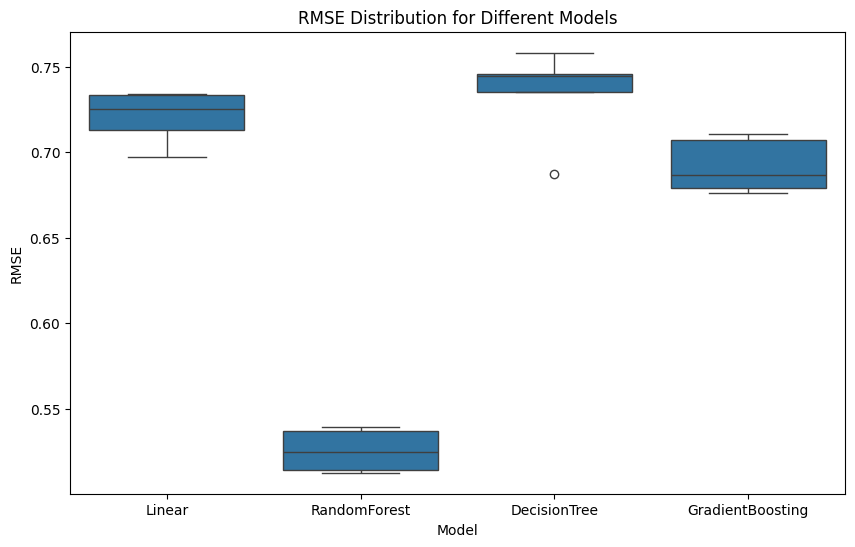

In [25]:
# Create a boxplot of RMSE values for each model
plt.figure(figsize=(10, 6))
sns.boxplot(x='model', y='rmse', data=rmse_df)
plt.title('RMSE Distribution for Different Models')
plt.ylabel('RMSE')
plt.xlabel('Model')
plt.show()


### Quiz

* Why do we use negative MSE with `cross_val_score` and how do we get RMSE from it?
* What do you expect the RMSE changes with more estimators in Random Forest and Gradient Boosting estimators

## Optional stretch

### What actually do random forest and gradient boosting estimator do?

#### Random forecst estimator

![Random forest estimator](https://www.researchgate.net/profile/Matthew-Reno-2/publication/326560291/figure/fig11/AS:651621029642243@1532369968679/Random-Forest-visualization.png)

[Source](https://www.researchgate.net/figure/Random-Forest-visualization_fig11_326560291)

#### Gradient boosting estimator

![Gradient boosting estimator](https://media.geeksforgeeks.org/wp-content/uploads/20250903173429506712/des.webp)

[Source](https://www.geeksforgeeks.org/machine-learning/ml-gradient-boosting/)

## Final evaluation on a holdout set
We'll hold out a test set once and evaluate the tuned non-linear model to show approximate generalisation performance.

In [26]:
# Final evaluation on a holdout set (manual scaling)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_inst = StandardScaler().fit(X_train)

# Why do we fit the scaler only on the training data and not on the test data? 
# What would happen if we fit it on the entire dataset before splitting?
X_train_s = scaler_inst.transform(X_train)

# transform the test set using the same scaler fitted on the training set to avoid data leakage and ensure that the model is evaluated on data that has been processed in the same way as the training data
X_test_s = scaler_inst.transform(X_test)


In [27]:

# Compare with RandomForest trained on same split 
rf = RandomForestRegressor(n_estimators=20, random_state=42)

rf.fit(X_train_s, y_train)
# What is this for?
y_pred_rf = rf.predict(X_test_s)
# What is this for?
rmse_rf_test = root_mean_squared_error(y_test, y_pred_rf)
print(f'Holdout RMSE (RandomForest): {rmse_rf_test:.3f}')

Holdout RMSE (RandomForest): 0.515


### Final quiz

* What would you suggest about the quality of this model?
* What could be the possible improvements for this model?

### Optional Stretch: using Pipeline

Above we wrote explicit loops to scale data and fit estimators.
`Pipeline` lets us chain transformers and estimators together and
integrate cleanly with tools like `GridSearchCV`.
Below are a few examples revisiting earlier sections using pipelines.

In [ ]:

# pipeline + GridSearchCV example tuning a random forest
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=20, random_state=42))
])
param_grid = {
    'rf__max_depth': [3, 5, 10],
    'rf__min_samples_split': [2, 5, 10]
}
gsearch = GridSearchCV(pipe_dt, param_grid, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
gsearch.fit(X, y)
best_params = gsearch.best_params_
best_rmse_grid = np.sqrt(-gsearch.best_score_)
print('Pipeline GridSearch best params:', best_params)
print(f'Best CV RMSE (RandomForest): {best_rmse_grid:.3f}')

## Key takeaways
- Use cross-validation to obtain reliable estimates of model performance rather than a single train/test split.
- Feature selection (univariate or model-based) can reduce overfitting and improve interpretability; evaluate selection inside cross-validation.
- Regularised linear models (Ridge, Lasso) often perform better than plain LinearRegression when multicollinearity exists.
- Tree-based models (RandomForest, GradientBoosting) can capture non-linear relationships and sometimes outperform linear models on this dataset.
- Always evaluate tuned models on a held-out test set to estimate generalisation performance.

---

<a id='what_is_classification'></a>
### Classification models 



#### What is classification?
*Classification* is a widely used type of supervised machine learning used to predict categorical outputs. 

Classification is something that we often instictively do in our daily lives. For example:

1. We classify whether someone is "happy" or "sad"
2. We classify some clothes as "new" or "old"
3. We classify different creatures as "mammals", "birds", "reptiles", and so on
4. We classify "fruits" differently from "vegetables"
5. We classify essays as a "pass" or "fail"

When we see an instance of something, we either recognise it and categorise it from memory, or, if we aren't familiar with the particular instance, we assign it a category based on its similarity to other instances that we do know. If you see an unknown plant that contains seeds, you might assign it the label "fruit", because you know that all fruits have seeds.



Classification involves setting up the rules that draw the decision boundaries between different categories, using previous information. For example, where does the precise boundary between "fruit" and a "vegetable" lie, or between "old" and "new" clothes? In some cases, the boundary is more obvious than others.

In the machine learning context, classification isn't about understanding these boundaries from a natural or social sciences perspective - instead, it's about inferring where the boundary is by brute-force, using previous examples and algorithms to determine how to categorise different instances.

More precisely, this previous information takes the form of labelled data. Labelled data means that the label, or *class* for each instance, is known - e.g. a creature is labelled as "mammal" or "bird", a person as "old" or "young".

Classification models are built using information from the labelled data, which then allows us to predict the class for new, unlabelled data.

#### How is classification different than regression?

Both classification and regression are supervised machine learning methods, where the aim is to predict a target variable output given input variables. 

The goal of regression is to predict a target variable that is *numerical and continuous*, whereas the goal of classification is to predict a target variable that is *categorical*. For both methods, the feature variables for the observations can be categorical or numerical, however.

Many approaches exist that can be used to solve both regression and classification problems - for example, Decision Trees, k-Nearest-Neighbours, Neural Networks, and Support Vector Machines.

In some cases, a regression problem can also be transformed into a classification problem. For example, you might encounter a regression problem, where you want to predict the price of a service (a continuous, numerical variable), but the buyers downstream are only interested in whether the price is "low", "medium" or "high" (a categorical variable). In cases such as these, we can "bin" the output variable into these categories, converting the regression problem into a classification one.



Examples of regression vs classification problems: 
- Predicting the number of viewers who will stream a new series, based on its reviews - *Regression*
- Predicting whether a TikTok user will click on your advert, based on their characteristics - *Classification*
- Predicting whether a patient will develop Alzheimer's disease, based on their brain scans - *Classification*
- Estimating the weight of a patient's heart, based on their medical data and scan -  *Regression*

#### What are the different types of classification problems? 

##### Binary classification 

In binary classification problems, the class variable can only two outcomes. Binary classification problems are very common. For example: 
- Classifying email as "spam" or "not spam"
- Classifying transactions as "fraudulent" or "not fraudulent" 
- Classifying a patient as "having a disease" or "not having a disease" 



##### Multiclass classification

Many techniques used in binary classification can directly extend to multiclass classification problems (also known as multinomial classification), where the class variable can take on more than two possible values. For example: 
- Classifying a vertebrate creature as "fish", "mammal", "reptile", "amphibian", or "bird"
- Classifying a shape as "circle", "square", or "star"

For some techniques like Naïve Bayes and Decision Trees/Random Forests, the extension to multiclass is immediate - whereas for others such as logistic regression and SVM, it can be done using a number of techniques such as One-vs-Rest (OvR) or One-vs-One (OvO).



##### Multilabel classification

In multilabel classification, each instances is given a set of labels or targets (rather than only one). For example, you may have an image that can be classified with several labels based on what it contains and its properties - such as "face", "portrait", "sky", etc. 

--



Examples of different classification problems 
- Email classification as "spam" or "not spam" - binary (since 1 class variable and 2 class values)
- Classification of a flower as one of 4 species - multiclass (since 1 class variable and > 2 class values)
- Identification of several faces in a a social media photo - multilabel (since multiple class variables)
- Satisfaction classification as "satisfied" or "neutral or dissatisfied" - binary (since 1 class variable and 2 class values)
- Predicting the class of a given students university degree - multiclass (since 1 class variable and > 2 class values)

#### What are example uses of classification?

- Technology: 
    * Is an email *spam* or *not spam*? A simple type of classifier known as a [Naive Bayes classifier]
    * Is your phone's [facial recognition software](https://towardsdatascience.com/face-recognition-for-beginners-a7a9bd5eb5c2) recognising the image as *your face*, *someone elses face* or *not a face*?
    * Is a driverless car, trying to work out a safe driving speed, driving along a *bumpy* or *smooth* surface? A simple type of classifier known as [Naive Bayes classifier](https://en.wikipedia.org/wiki/Naive_Bayes_spam_filtering) is often used for this purpose.
    * Is a handwritten digit a *1*, *2*, *3* etc.? This is a classic problem in the history of machine learning classification, that can be investigated with the famous [MNIST dataset](https://medium.com/@himanshubeniwal/handwritten-digit-recognition-using-machine-learning-ad30562a9b64) that is accessible through `sklearn`.
- Finance: Is a credit card transaction *fraudulent* or *not-fraudulent*? The online bank [Monzo](https://monzo.com/blog/2017/02/03/fighting-fraud-with-machine-learning) discusses their application of this.
- Medicine: Is a tumour *malignant* or *benign*? 
- Marketing: Is a user *likely* to purchase a service or *not likely*? 
- Astrophysics: Is a galaxy *spiral* or _elliptical_ based on an image?

<a id='classification_models'></a>
### What is a Classification model?



*Classification models* are found using various classification algorithms. The algorithms are carried out on existing, labelled data which builds a model.

Once the classifcation model has been built, it can then be used to predict the outcomes for new, unlabelled data.



#### What are examples of different classification algorithms ?

There are many different types of classification algorithms. Some of the most popular ones include:
- Logistic Regression 
- Decision Trees
- Naïve Bayes
- Support Vector Machines (SVM)
- k-Nearest Neighbours (kNN)
- Ensemble Methods (such as Random Forests, AdaBoost, Gradient Boosts)
- Neural Networks

The choice of algorithm you use to build a classification model depends on the dataset at hand, the performance of the model, and the context of the problem.

#### What is logistic regression? 

*Logistic regression* (or *logit regression*) is a classification algorithm that classifies observations by predicting the probability that they belong to a certain class based on its features.

Logistic regression is often used for binary classification problems, but it can also be extended to the multiclass case. For now, we'll focus on the binary case.



##### Logistic regression and linear regression

A logistic regression model is set up similarly to a linear regression problem, but the model is modified to adjust for the prediction of a binary output variable, rather than the prediction of a continuous, numerical variable.

There may be some cases where you begin to approach a problem using linear regression but then later decide that logistic regression may be more appropriate. For example, you might be predicting a continuous variables such as size, but then realise that a binary classification would be more useful. To address this, you can "bin" the output variable into binary categories (e.g. "*large*" or "*small*"). 

In certain cases, a less granual representation of the output variable might be more useful, and so logistic regression provides a more useful form of analysis than linear regression.



##### The logistic regression model

Logistic regression classifiers build a linear decision boundary like so:

![Decision Boundary](https://codefinity-content-media.s3.eu-west-1.amazonaws.com/b71ff7ac-3932-41d2-a4d8-060e24b00129/DecisionBoundary.png)<br> 
<br> 

In practice, it's unlikely that data is perfectly linearly separable - if it's roughly so, however, linear classifiers such as logistic regression perform well.



The logistic regression algorithm constructs a function that uses one or more independent variables to determine the dependent variable outcome. 

Image we have a binary dependent variable **_y_** and two numerical features **x<sub>1</sub>** and **x<sub>2</sub>**. If we built a model by constructing a linear combination of the features, it would result in the following equation:

> **m = w<sub>1</sub>x<sub>1</sub> + w<sub>2</sub>x<sub>2</sub> + b**

where **w<sub>1</sub>**, **w<sub>2</sub>** and **b** are model parameters. In this equation, the output **m** can take on any numerical value ranging from minus infinity to infinity.



Assigning this value to __*y*__ doesn't work for a binary classification problem. To address this issue, we apply the *logistic function* (also known as the *sigmoid function*) to the above output **m**, which is defined as: 

> $\sigma(m) = \frac{e^m}{1+e^m}$


The logistic function approaches 1 as **m** gets very large and positive (because **e<sup>m</sup>** gets very large), and the function approaches 0 as **m** gets very large and negative (because **e<sup>m</sup>** goes to 0). This constrains the output of the linear model into the range 0-1.

As a result, the output value **σ(*m*)** that falls between 0-1 is interpreted as the *probability* that the output is 1.

The logistic regression model optimises the model parameters **w<sub>1</sub>**, **w<sub>2</sub>** and **b** to give the best fitting model for the dataset at hand. 
- **σ(*m*)** = 0 corresponds to the output being 0
- **σ(*m*)** = 1 corresponds to the output being 1
- **σ(*m*)** = any other value means the corresponding probability that the output is 1

#### What is the Decision Tree algorithm? 

*Decision Trees* are a widely-used, powerful, and intuitive classification technique. Decision Trees perform classification by asking a series of decision questions that split the data into two or more groups. 

For example, when trying to classify an animal (as "mammal", "bird", "reptile" etc.), you can imagine asking a series of questions, with latter questions depending on the answer to previous questions. You might first ask "*Is it warm-blooded?*", and if the answer is "*Yes*", you might then ask "*Does it give birth to live young?*", and so on. 

With this approach, the goal is that a series of appropriately posed questions would allow us to correctly classify any instance.





![Animal decision.jpeg](https://www.emagine.org/wp-content/uploads/2023/07/non-Linear-Machine-Learning-Algorithms-Decision-Trees.jpg)

[Source](https://www.emagine.org/wp-content/uploads/2023/07/non-Linear-Machine-Learning-Algorithms-Decision-Trees.jpg)
> *Caption*: An example of a decision tree which asks a series of questions to classify an animal. 

##### Anatomy of a Decision Tree

Decision trees consist of *nodes* that split into more nodes: 
- *Nodes*: The points in a tree where a decision question gets asked and the data splits as a result.
- *Root node*: The node at the start of the Decision Tree where the entire dataset is first split.
- *Parent and child nodes*: A node that is split into sub-nodes is called a *parent node* of the sub-nodes, and the sub-nodes are called the *child node* of that parent node.
- *Terminal (leaf) nodes*: The final nodes at the bottom of the tree.





![Decision tree example](https://www.xoriant.com/sites/default/files/uploads/2017/08/Decision-Trees-modified-1.png)

#### *Challenge*: Compare applications of linear regression and logistic regression 
Note down two high-level examples of when you might apply linear regression to solve a supervised learning problem and two examples for when you instead would use logistic regression.

In [ ]:
## Write your examples here as comments or markdown

<a id='interpreting_classification_models'></a>
### How do I interpret Classification models? 



#### How do I interpret the outcome of a logistic regression model?

The logistic regression model gives returns the probability that an instance belongs to the positive class. To predict the final outcome of an instance, the predicted probability  is compared to a *decision threshold* (or *classification threshold*).

The decision threshold converts the probabilities into binary outputs by binning the values based on where it falls compared to the threshold.  

By default, the decision threshold is 0.5: 
- If **σ(*y*)** < 0.5, we predict that _**y**_ is 0
- If **σ(*y*)** > 0.5, we predict that _**y**_ is 1

Althought 0.5 is the default value, there is more nuance in choosing the optimal value, which is *problem-dependent*.



#### How do I interpret the outcome of a Decision tree model? 

The leaf nodes of a Decision Tree provide the prediction for any new instance that ends up there, based on the proportion of the training data outcomes in that node.

For example, if 80% of the training data in a given leaf node is class A, and 20% of it is class B, then for any new data point that ends up in this node, we would predict that it's of class A (with a probability of 0.8). As a result, the tree gives us both a prediction of an instance's class along with the probability that it belongs to that class.

### How do you implement logistic regression in Python?



There are several implementations of logistic regression in Python's `sklearn.linear_model`.
- The function `LogisticRegression` offers a number of sophisticiated numerical algorithms (including gradient descent) that you can choose from to solve the logistic regression optimisation problem. 
- `SGDClassifier` (which stands for stochastic gradient descent) with default arguments is an SVM classifier, but setting the argument `loss = log` chooses the loss function to be that of logistic regression.

The steps for running logistic regression in Python are:

1. Setup the model object by calling `LogisticRegression` and setting any arguments such as `solver` etc.
2. Train the model by running `.fit()`
3. Make predictions with the model, by using `.predict()` or `.predict_proba()`

`LogisticRegression` automatically uses 0.5 as the decision threshold, and this cannot be changed. However, the threshold can tweaked manually by using `.predict_proba()` to generate the probabilities for each class (rather than the predictions themselves), and then generating the predictions by comparing the probability of the second class to some user-defined threshold. 

#### Note: this part is more advanced

Other features of `LogisticRegression`: 
- *Regularisation*: Logistic regression, just like other linear models, can be regularised with a L<sub>1</sub> or L<sub>2</sub> term - a L<sub>2</sub> term is added by default in `sklearn`. The strength of regularisation is controlled by the argument `c` - larger `c` means a less regularised model.
- *Algorithm for the optimisation problem*: The `LogisticRegression` class has a number of numerical algorithms available through the `solver` argument to solve the optimisation problem of the cost function - you can look into these and tune this argument if you'd like, but generally the default works well. Rather than gradient descent the default is something known as L-BFGS.
- *Polynomial features*: To implement logistic regression with polynomial features, you first want to create the polynomial features using `sklearn.preprocessing.PolynomialFeatures`. Once you have generated the new training set with polynomial features and/or interaction terms, you can use the `LogisticRegression` function as usual. You can then create a `LogisticRegression` object and run `.fit()` on your expanded training set, in the usual way. Note that when it comes to evaluating your model, you will need to perform this same transformation on the test set however. 

#### *Demo*: Use `LogisticRegression()` from `sklearn` to train a model

Let's see how a simple classification analysis is performed in Python using a Decision Tree classifier. For this challenge, we'll work with a medical dataset from the [UCI Repository](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic%29).

##### Imports

In [28]:
# Import the libraries 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

In [29]:
# Import the data
# If return_X_y is True, returns (data, target) instead of a bunch object 
data, target = load_breast_cancer(return_X_y=True, as_frame=True)

##### Data exploration

In [30]:
# Inspect the first 5 rows
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [31]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

There are 30 medical variables (columns) on each patient measuring things related to breast cancer. The target variable (diagnosis) isn't part of this table since it was separated when the data was loaded in.

In [32]:
# Get the target variable counts
print(f'Count of Malignant tumors {target.value_counts()[0]}')
print(f'Count of Benign tumors {target.value_counts()[1]}')

Count of Malignant tumors 212
Count of Benign tumors 357


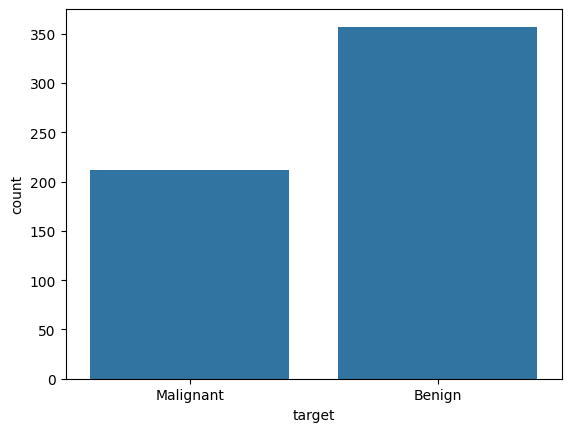

In [36]:
# Replace the class values (0 and 1) 
target = target.replace([0,1], ['Malignant', 'Benign'])

# Plot the target classes with a function in seaborn that shows the count of each class in a bar plot
ax = sns.countplot(x=target)

##### Preprocessing

In [37]:
# Rename features (X) and target (y)
X = data
y = target

# What's the purpose of this step? Why do we need to rename these variables?

In [39]:
# Perform train/test split 
from sklearn.model_selection import train_test_split

# Split using a 80/20 ratio and setting the seed
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape
print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [40]:
# Scale the data

# {Fill in the blank to create a StandardScaler instance}
sc = StandardScaler()
# Fit the scaler on the training data and transform both training and test data
X_train_scaled = sc.fit_transform(X_train)

#### Train the model

`sklearn` library's logistic regression classifier `LogisticRegression()` is found in the `linear_model` [sublibrary](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).

The steps to train a `LogisiticRegression()` model:
1. Import the `LogisticRegression` function
2. Store the function with default arguments into a new variable 
3. Run the `.fit()` method using the scaled training features and the training labels

In [47]:
# Import LogisticRegression
from sklearn.linear_model import LogisticRegression

# Store the function with default arguments
model_lr = LogisticRegression(random_state=123)

# Fit the model to the (scaled) training data and training labels
model_lr.fit(X_train_scaled, y_train) # fill in the blank to fit the logistic regression model on the scaled training data and training labels

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",123
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

#### Explore the predictions of the model

The `LogisticRegression()` has a `.predict()` method that can be used after running `.fit()` to make predictions on our data.

Using the model we just trained, we can see what predictions it will make on the test set.

Before applying `.predict(),`, the same preprocessing applied to the training set must be applied to the test set.

We can take a look at these predictions which should be a 1-dimensional `numpy` array of "Malignant" and "Benign" values

In [48]:
# Scale the test set 
X_test_scaled = sc.transform(X_test)

In [49]:
X_train_scaled

array([[-1.44075296, -0.43531947, -1.36208497, ...,  0.9320124 ,
         2.09724217,  1.88645014],
       [ 1.97409619,  1.73302577,  2.09167167, ...,  2.6989469 ,
         1.89116053,  2.49783848],
       [-1.39998202, -1.24962228, -1.34520926, ..., -0.97023893,
         0.59760192,  0.0578942 ],
       ...,
       [ 0.04880192, -0.55500086, -0.06512547, ..., -1.23903365,
        -0.70863864, -1.27145475],
       [-0.03896885,  0.10207345, -0.03137406, ...,  1.05001236,
         0.43432185,  1.21336207],
       [-0.54860557,  0.31327591, -0.60350155, ..., -0.61102866,
        -0.3345212 , -0.84628745]], shape=(455, 30))

In [50]:
# Make predictions on the scaled test set
y_pred = model_lr.predict(X_test_scaled)

In [51]:
# Inspect the first 10 predictions
y_pred[:10]

array(['Benign', 'Malignant', 'Malignant', 'Benign', 'Benign',
       'Malignant', 'Malignant', 'Malignant', 'Benign', 'Benign'],
      dtype=object)

In [52]:
## Evaluate the model using accuracy score
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.3f}')

Accuracy: 0.974


### Group Challenge

We have applied `StandardScaler` in fitting the logistic regression model.
Let's try with other scalers to see if it improves the performance of the model in terms of accuracy score

**Tasks**

* Use `MinMaxScaler` and `RobustScaler` to transform the train data
* Retrain the model using the same `X_train`
* Give the accuracy score of the newly trained model using `X_test`
* Compare their accuracy scores with the train data being transformed using `StandardScaler`
* **Optional Stretch**: Try to use a loop to apply the transformation, training and evaluation. 
* **Optional Stretch**: Use a pipeline to perform all transformation, training and evaluation. 

In [ ]:
# write your code here: try a different scaler and see if it improves the accuracy score
# Remember to import necessary sublibraries in sklearn
from sklearn.preprocessing import MinMaxScaler, RobustScaler
# set minmaxscaler


In [ ]:

# apply the scaler to the training data and transform the test data


In [ ]:


# fit the logistic regression model on the scaled training data



In [ ]:

# make predictions on the scaled test set


In [ ]:

# evaluate the model using accuracy score


In [ ]:
# set RobustScaler


In [ ]:

# apply the scaler to the training data and transform the test data


In [ ]:

# fit the logistic regression model on the scaled training data


In [ ]:

# make predictions on the scaled test set


In [ ]:

# evaluate the model using accuracy score


In [ ]:
## Challenge: try to use a pipeline to combine the scaling and modeling steps and see if you can get the same accuracy score without having to manually scale the data before fitting the model.
# Remember to import Pipeline from sklearn.pipeline at the top of the notebook if you haven't already.




### Optional stretch

#### How does the logistic regression algorithm find a classification model? 





The logistic regression algorithm finds the optimal values of the model parameters **w<sub>i</sub>** and **b** to give the best-fitting model.

As with any machine learning algorithm, the logistic regression algorithm takes a mathematical quantity known as the *loss* or *cost function* and optimises (i.e., minimises) it with respect to the model parameters.  The cost function is a function of the differece between the true and estimated values of the data.

The process to learn the optimal parameters is:

1. Choose a cost function suitable for the task
2. Choose a numerical optimisation technique
3. Apply the optimisation technique to the chosen cost function and find the optimal model parameters for the data at hand

##### 1. Choose a cost function suitable for the task
For logistic regression, the choice of the cost function is called the *cross-entropy* or *log-loss* cost function:

Visualise the cost function
![cost function](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*_NeTem-yeZ8Pr9cVUoi_HA.png)


Mathematical representation of the cost function for all samples, 
![Cost function in mathematical notation](https://miro.medium.com/v2/resize:fit:720/format:webp/1*dEZxrHeNGlhfNt-JyRLpig.png)



The *y*<sup>(i)</sup> values are the actual observed values and the *y*<sup>(i)</sup> with hats are the model predictions (which depend on the model parameters). 

[Source](https://medium.com/data-science/optimization-loss-function-under-the-hood-part-ii-d20a239cde11)

The expression within the summation (everything following the $\Sigma$ symbol) is referred to as a *loss function*. The loss function is the cost function for a single training instance.
- If the actual output for an instance is y=1, then the loss function reduces to the first term -log(σ) (where we are using σ to denote our prediction). This loss is small when σ is close to 1 (when the model is likely to predict y=1) and large when σ is close to 0 (when the model is likely to predict y=0).
- If y=0, then the loss function reduces to -log(1-σ). This loss is small when σ is close to 0 (when the model is likely to predict y=0) and large when σ is close to 1 (when the model is likely to predict y=1).

We can see that the loss function is small when the actual and predicted values agree, and large otherwise.

The cross-entropy or log-loss cost function is then the sum of this loss function across the whole dataset (i.e., for each instance).

##### 2. Choose a numerical optimisation technique

Once a suitable cost function is chosen, the logistic regression problem is solved by applying an optimisation technique to the chosen cost function.

In machine learning, the most common choice is *gradient descent*, which is a general purpose optimisation algorithm used to find the minimum of a cost function.

Gradient descent is an approach where the algorithm starts with arbitrary values of the model parameters, and continues to take "small steps" in parameter space such that the cost function keeps on going down, until it reaches the minimum.



##### 3. Apply the optimisation technique to the chosen cost function to find the optimal model parameters for the data

For a logistic regression problem the gradient descent optimisation technique can be applied to the log-loss cost function to find the minimum and therefore the optimal parameters for the model: 

1. Start with some arbitrary values of the parameters and compute the cost function on the training set with these parameter values (the cost function is unlikely to be the minimum value right away)
2. Scan the different "directions" in parameter space that the algorithm can step in, and then take a "small" step (where "small" is given by the *learning rate*) in the direction that will lower the value of the cost function by the largest amount. This directly is given mathematicaly by the *gradient* of the cost function.
3. Repeat step 2 until the minimum value of the cost function is found. If the algorithm has worked correctly, eventually all directions in the parameter space look flat (within some threshold) around the current position, indicating it's at the minimum value of the cost function. 



### Visualising gradient descent algorithm

![gradient.png](https://miro.medium.com/v2/resize:fit:720/format:webp/0*QGWG1SbMjNjQ2wWk.png)

> *Caption*: Gradient descent - given random initial values of the parameters (here the single parameter **w**), the algorithm steps down in the direction of maximum gradient (with step size determined by the learning rate) until it reaches the minimum of the cost function.

There are other numerical algorithms that can be used to solve the logistic regression problem, and some of these can also be used by the `sklearn` implementation of logistic regression.

[Source](https://medium.com/intro-to-artificial-intelligence/logistic-regression-using-gradient-descent-bf8cbe749ceb)

## Another classification algorithm - decision tree classifier

### How do you implement Decision Trees in Python?



The `sklearn` library in Python has an implementation of the Decision Tree model called [CART](https://scikit-learn.org/stable/modules/tree.html#tree-algorithms-id3-c4-5-c5-0-and-cart) (Classification and Regression Trees).

This tree is built iteratively by producing binary splits and  minimising what is called the *weighted impurity* at each node.

We can use the `DecisionTreeClassifier` class from the `sklearn.tree` sublibrary to implement this model.

It's structured very similarly to many `sklearn` classes, with the steps being: 

1. Setup the model object by calling `DecisionTreeClassifier()` and setting any arguments, such as `criterion`, `max_depth`, `min_samples_split`, `class_weight`, etc.
2. Train the model by running `.fit()`
3. Make predictions with the model, by using `.predict()` or `.predict_proba()`
4. Access model information via various attributes such as `.feature_importances_`

#### *Demo*: Use `DecisionTreeClassifier()` from `sklearn` 

Let's see how a simple classification analysis is performed in Python using a Decision Tree classifier. For this challenge, we'll work with a medical dataset from the [UCI Repository](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic%29).

##### Imports

In [ ]:
# Import the libraries 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

In [ ]:
# Import the data
# If return_X_y is True, returns (data, target) instead of a bunch object 
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

##### Preprocessing

In [ ]:
# Replace the class values
y = y.replace([0,1], ['Malignant', 'Benign'])

# Perform a train/test split using a 80/20 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shape
print(X_train.shape)
print(X_test.shape)

##### Train the model

We can now build and fit the Decision Tree model using the `sklearn` class `DecisionTreeClassifier`, which takes a number of arguments:
- `criterion` determines which impurity metric is used in the algorithm, with options `"entropy"` or `"gini"`
- Several arguments can restrict the complexity of the tree if changed from the default value `None`, such as `max_depth`, `max_features`, `min_samples_split`, `max_leaf_nodes`, etc.

For now, let's set a tree depth of 2 using entropy as its impurity metric.

In [ ]:
# Import the DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

# Instantiate a class object with max depth of 2 
# and using entropy as the impurity metric
tree_model = DecisionTreeClassifier(criterion='entropy', max_depth=2, random_state=123)

# Fit the model to the training set
tree_model.fit(X_train, y_train)

### Quiz

* What do you expect the tree look like if `max_depth` is changed from 2 to 3? Draw it using tldraw.



##### Visualise the model 

In [ ]:
# Import the tree library
from sklearn import tree

# Set the dpi to 300 to make the image clearer
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), dpi=300)

# Plot the tree
tree.plot_tree(tree_model,
               feature_names = X_train.columns,
               class_names=tree_model.classes_,
               filled = True);

Given a new instance (i.e., patient), the resulting tree first asks about the feature `mean concave points` being smaller or equal to a particular value. Based on the answer to this question, it then asks about the value of `worst radius` or `worst perimeter`. 

For our tree, with a `max_depth` of 2, it stops here, and the instance will be classified as either "Malignant" or "Benign", depending on which class has more training instances in that particular leaf node.

The tree will look different if you change any of the hyperparameters (e.g. `max_depth`, `criterion`) or train on different data. 

##### Make a prediction using the tree 

We'll now pick a random instance from the training set (choose any row from the `X_train` data frame) and assign this to a variable called `X_example`. 

In [ ]:
# Take all columns from row 200
X_example = X_train.loc[200,:]

# Print (the example patient)
X_example

We can use our model to make a prediction on the instance `X_example` using the `predict()` method. 

We can also access the probabilities using the `predict_proba()` method.

In [ ]:
# Make a class prediction for X_example
# (which is in brackets to be a 2D array input)
tree_model.predict([_____________]) # fill in the blank to make a prediction for the example patient using the decision tree model

In [ ]:
# Use our model to compute the probabilities that X_example 
# is in each of the 2 possible classes
tree_model.predict_proba([X_example])

This gives the probabilities of the instance being in either of the two classes according to the model. 

For this instance, the probability of being Malignant was around 98% and the probbility of being Benign around 2%.

The probabilities are calculated based on how many training instances from each class are in the leaf node (at the bottom of the tree) that this new instance falls into. The prediction will then be the class with the *highest probability*.

In [ ]:
# Evaluation using accuracy score
from sklearn.metrics import accuracy_score
y_pred = tree_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.3f}')

### Optional stretch - How do Decision Tree algorithms create the optimal decision tree model? 

##### 1. Partition

To "*best split the data*" when partitioning means to split the data such that the outgoing data is more *pure* than the incoming data - i.e., each child node contains data that is more skewed towards one of the classes than its parent node. *Purity* can be measured in a number of ways. Common metrics include [entropy](https://medium.com/coinmonks/what-is-entropy-and-why-information-gain-is-matter-4e85d46d2f01) and the and the [Gini index](https://blog.quantinsti.com/gini-index/).

##### Entropy 

Entropy is a measure of information disorder, or uncertainty in the sample as each node. Entropy ranges from 0 (totally pure) to 1 (totally mixed):

What is the formula for Entropy?

![Entropy formula](https://miro.medium.com/v2/resize:fit:640/format:webp/1*nNY_7_aWRwp8E2DyGduEPg.png)



where *p<sub>i</sub>* is the fraction of the data in class *i*, and *i* is summed over all possible class values. 




For example, if the samples at a node is completely mixed and equaly divided, then the entropy is 1, meaning maximum uncertainty.

However, if the samples at a node are completely homogeneous and all belong to the same class, then the entropy is 0, meaning minimum uncertainty and the node is totally pure. 

In other words, in decision trees, we want nodes that have *low entropy* (and *high purity*).

Entropy function for different values of classifiers

![Entropy diagram](https://miro.medium.com/v2/resize:fit:640/format:webp/1*M15RZMSk8nGEyOnD8haF-A.png)



> *Caption*: Plot of entropy as the fraction of data in one of two classes varies from 0 to 1. Source: "Data Science for Business" - Foster Provost & Tom Fawcett*

The plot shows the relationship between entropy on the *y*-axis and the proportion of the data belonging to the positive class on the *x*-axis:
- **p(+)=0**: When all samples at the node are negative (when the proportion of data points in the positive class is 0), the entropy is 0. 
- **p(+)=0.5**: As the proportion of samples in the positive class increases up to 0.5 (i.e., when the node is half the positive class and half the negative class), the entropy is 1. 
- **p(+)=1**: The curve symmetrically decreases as the proportion of positive instances increases until all samples are positive. At this point, the entropy is 0 again.

##### The Gini Index

Similarly, the Gini Index measures purity and ranges from ranges from 0 (totally pure) to 0.5 (totally mixed) for the binary case:

#### Gini index visualised

![Gini index](https://substackcdn.com/image/fetch/$s_!mL76!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F2208790a-1ad9-4f70-bd3e-7579380f787f_744x400.jpeg)

where *p<sub>i</sub>* is the fraction of the data in class *i*, and *i* is summed over all possible class values. 

In practice, it usually makes little difference which impurity metric is used in building the tree - it is easy to try both the Gini Index and entropy in `sklearn`.

##### Greedy algorithms
At each split point, decision tree algorithms try to maximise the difference in a node's entropy or Gini index value before and after splitting, aiming for a large reduction (i.e., increase in purity). 

For example, if you imagine calculating the entropy reduction for all attributes in your dataset until you find the one that has the highest, this would be the attribute that would be chosen by the algorithm as the next node.

As a result, decision tree algorithms are known as "*greedy*" algorithms since they shoot for *maximum purity at every split point*.

This is the ultimate aim of the algorithms - start with a messy impure dataset at the top that has data in all classes, and end up with leaf nodes that are as pure as possible. This purity of the leaf nodes is important as it allows us to make confident predictions about new instances of data.

##### 2. Recursion

The algorithm is *recursive* because the process repeats itself - when the data has been split by a first node, it moves to the next branch to find the next best split, and so on. 

The process is repeated for all child nodes until either:
- The node is completely pure 
- All features values of the node are the same 
- Some *stopping conditions* terminate the algorithm

Some examples of stopping conditions are:
- Setting the maximum depth of the tree (e.g., setting a limit to a maximum of 2 layers of nodes/splits)
- Setting a minimum number of samples required at a node to consider splitting it further 
- Setting a maximum number of leaf nodes 

As a result, the class label with the highest proportion at each leaf node will be assigned to any new data that ends up in that leaf. 



###### Overfitting

Stopping conditions are known as *regularisation* strategies that handle the common issue that decision trees have with *overfitting* - an issue that happens when our model fits the training data too well (high training accuracy), but doesn't generalise to an unseen test set (low test accuracy). This means the model has bad *generalisation*, and the phenomenon usually occurs from a model having too much complexity for the size or dimensionality of the dataset. 

Decision trees are *non-parametric* models, meaning that the number of parameters isn't determined before model training. As a result, they are prone to overfitting - since, if left unconstrained, they tend to continue to splitting nodes and build very complex trees.

### Review: Intro to Classification

- Understand the concept of classification and its importance in machine learning and data analysis
- Identify different types of classification problems, such as binary, multi-class, and multi-label classification
- Understand common classification algorithms, including decision trees, logistic regression, and k-nearest neighbors (k-NN)
- Compare and contrast the strengths and limitations of various classification algorithms, enabling informed algorithm selection for different datasets
- Evaluate the performance of classification models using appropriate evaluation metrics, such as accuracy, precision, recall, F1 score, and ROC curves
- Implement classification algorithms in Python using popular libraries such as scikit-learn
- Gain hands-on experience in preprocessing and feature engineering techniques to enhance classification model performance
- Apply best practices for model training, testing, and validation, including strategies for cross-validation and hyperparameter tuning to optimise classification models

#### What should I learn next?

In the next workshop we will continue our study of classification model and evaluation metrics

### What packages does this chapter use?

Sklearn, numpy, pandas

## Appendix

### Resources

- [Fighting Fraud with Machine Learning at Monzo](https://monzo.com/blog/2017/02/03/fighting-fraud-with-machine-learning): Is a credit card transaction fraudulent or not-fraudulent? Read how Monzo is fighting fraud with Machine Learning. (6 min read) 
- [Face Recognition](https://towardsdatascience.com/face-recognition-for-beginners-a7a9bd5eb5c2): For Beginners - A comprehensive overview of the techniques and methods behind face recognition.? (9 min read)
- [Handwritten Digit Recognition using Machine Learning](https://medium.com/@himanshubeniwal/handwritten-digit-recognition-using-machine-learning-ad30562a9b64): Read how classification and other machine learning techniques you are already familiar with (such as neural nets) are used in handwritten digit recognition. (17 min read)
- [A visual introduction to machine learning](http://www.r2d3.us/visual-intro-to-machine-learning-part-1/)
- [MLU explain: Logistic regression](https://mlu-explain.github.io/logistic-regression/)
- [StatQuest video on Logistic Regression (up to 5:15)](https://www.youtube.com/watch?v=yIYKR4sgzI8) (5min watch)
- [4 Logistic Regressions Examples to Help You Understand](https://magoosh.com/data-science/4-logistic-regressions-examples/) (2min read)
- [StatQuest video on Logistic Regression (from 6:10 to 8:08)](https://www.youtube.com/watch?v=yIYKR4sgzI8) (2 min)

---